# Tugas 1b: Sentiment Analysis Data Augmentation & Model Comparison
## Poin E - Model Performance Comparison (Original vs Augmented Data)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
import warnings
warnings.filterwarnings('ignore')

# Set paths
BASE_PATH = Path(r"c:\Users\mikba\Downloads\Documents\LPDP-SentimentAnalysis")
# Original & test come from the same train/test split that c.ipynb used (notebook 9 output)
DATA_ORIGINAL  = BASE_PATH / "outputs" / "output_split" / "track_a_train.csv"
DATA_TEST      = BASE_PATH / "outputs" / "output_split" / "track_a_test.csv"
DATA_AUGMENTED = BASE_PATH / "notebooks" / "tugas-1b" / "train_balanced_flant5_track_a.csv"

print("✅ Libraries imported successfully")
print(f"   DATA_ORIGINAL  → {DATA_ORIGINAL}")
print(f"   DATA_TEST      → {DATA_TEST}")
print(f"   DATA_AUGMENTED → {DATA_AUGMENTED}")


c:\Users\mikba\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported successfully
   DATA_ORIGINAL  → c:\Users\mikba\Downloads\Documents\LPDP-SentimentAnalysis\outputs\output_split\track_a_train.csv
   DATA_TEST      → c:\Users\mikba\Downloads\Documents\LPDP-SentimentAnalysis\outputs\output_split\track_a_test.csv
   DATA_AUGMENTED → c:\Users\mikba\Downloads\Documents\LPDP-SentimentAnalysis\notebooks\tugas-1b\train_balanced_flant5_track_a.csv


In [1]:
import torch, subprocess, sys

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
print(f"CUDA version     : {torch.version.cuda}")
print(f"cuDNN version    : {torch.backends.cudnn.version()}")
print(f"GPU count        : {torch.cuda.device_count()}")

# Check if PyTorch was installed with CUDA support or CPU-only
if "+cpu" in torch.__version__ or torch.version.cuda is None:
    print("\n⚠️  PyTorch CPU-only build detected!")
    print("   Perlu install ulang PyTorch versi CUDA.")
elif not torch.cuda.is_available():
    print("\n⚠️  PyTorch CUDA build ada, tapi CUDA tidak terdeteksi.")
    print("   Kemungkinan: driver NVIDIA belum ter-install atau GPU tidak ada.")
else:
    print(f"\n✅ GPU siap: {torch.cuda.get_device_name(0)}")


PyTorch version  : 2.12.0+cu126
CUDA available   : True
CUDA version     : 12.6
cuDNN version    : 91002
GPU count        : 1

✅ GPU siap: NVIDIA GeForce RTX 4060 Laptop GPU


In [12]:
import subprocess, sys
# Install PyTorch CUDA 12.6 ke Python interpreter yang dipakai kernel ini
result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "torch", "torchvision", "torchaudio",
     "--index-url", "https://download.pytorch.org/whl/cu126",
     "--upgrade", "-q"],
    capture_output=True, text=True
)
print("STDOUT:", result.stdout[-2000:] if result.stdout else "(kosong)")
print("STDERR:", result.stderr[-2000:] if result.stderr else "(kosong)")
print("Return code:", result.returncode)


STDOUT: (kosong)
STDERR:   WARNING: The scripts torchfrtrace.exe and torchrun.exe are installed in 'c:\Users\mikba\AppData\Local\Python\pythoncore-3.14-64\Scripts' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

Return code: 0


## Section 1: Load Dataset and Inspect Labels

In [3]:
# Load original dataset
df_original = pd.read_csv(DATA_ORIGINAL)

print("="*70)
print("ORIGINAL DATASET - INSPECTION")
print("="*70)
print(f"\nShape: {df_original.shape}")
print(f"\nColumns: {df_original.columns.tolist()}")
print(f"\nData types:\n{df_original.dtypes}")
print(f"\nMissing values:\n{df_original.isnull().sum()}")

# Inspect text column
print(f"\n{'Text Columns Analysis':^70}")
print(f"Text column: 'text_clean'")
print(f"Sample text: {df_original['text_clean'].iloc[0][:150]}...")

# Inspect sentiment labels
print(f"\n{'Sentiment Distribution':^70}")
print(df_original['Sentiment'].value_counts())
print(f"\nSentiment distribution (%):")
print((df_original['Sentiment'].value_counts(normalize=True) * 100).round(2))

# Label unique values
print(f"\nUnique sentiment labels: {df_original['Sentiment'].unique().tolist()}")

ORIGINAL DATASET - INSPECTION

Shape: (830, 4)

Columns: ['doc_id', 'text_clean', 'Sentiment', 'label_encoded']

Data types:
doc_id           int64
text_clean         str
Sentiment          str
label_encoded    int64
dtype: object

Missing values:
doc_id           0
text_clean       0
Sentiment        0
label_encoded    0
dtype: int64

                        Text Columns Analysis                         
Text column: 'text_clean'
Sample text: lembaga kelola dana didik lpdp angin segar terima beasiswa alumni lpdp milik fleksibilitas panjang tinggal negeri selesai studi direktur utama lpdp su...

                        Sentiment Distribution                        
Sentiment
positive    308
neutral     273
negative    249
Name: count, dtype: int64

Sentiment distribution (%):
Sentiment
positive    37.11
neutral     32.89
negative    30.00
Name: proportion, dtype: float64

Unique sentiment labels: ['neutral', 'positive', 'negative']


## Section 2: Analyze Class Distribution and Data Quality

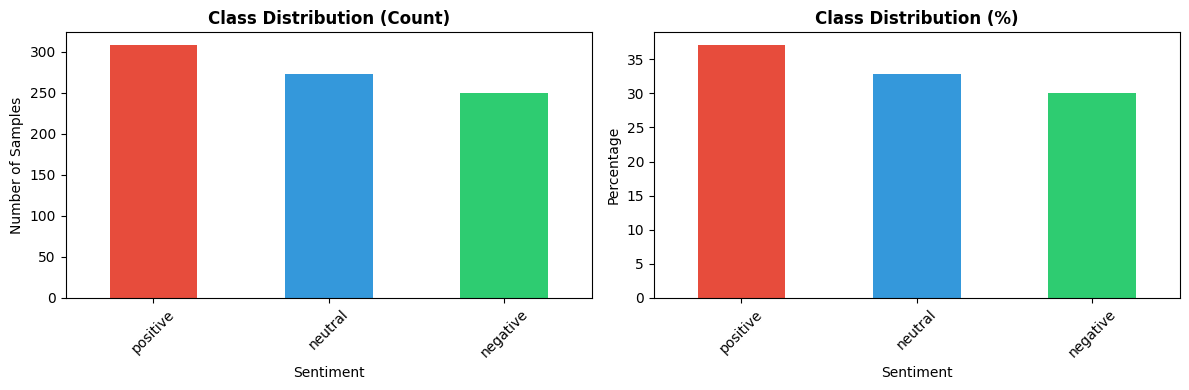

CLASS IMBALANCE ANALYSIS

Imbalance Ratio: 1.24x (max/min)
Minority class: negative (n=249)
Majority class: positive (n=308)

                        Text Length Statistics                        
count     830.00
mean      258.53
std       161.00
min        13.00
25%       160.00
50%       214.00
75%       304.00
max      1344.00
Name: text_length, dtype: float64

                       Text Length by Sentiment                       
           count    mean     std   min     25%    50%    75%     max
Sentiment                                                           
negative   249.0  245.30  167.32  13.0  156.00  203.0  273.0  1344.0
neutral    273.0  265.37  161.02  15.0  154.00  220.0  328.0   909.0
positive   308.0  263.17  155.58  24.0  171.75  217.0  313.0   918.0


In [4]:
# Analyze class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class count
df_original['Sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xlabel('Sentiment')
axes[0].tick_params(axis='x', rotation=45)

# Class percentage
(df_original['Sentiment'].value_counts(normalize=True) * 100).plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_title('Class Distribution (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Sentiment')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("="*70)
print("CLASS IMBALANCE ANALYSIS")
print("="*70)
class_counts = df_original['Sentiment'].value_counts()
max_count = class_counts.max()
imbalance_ratio = max_count / class_counts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}x (max/min)")
print(f"Minority class: {class_counts.idxmin()} (n={class_counts.min()})")
print(f"Majority class: {class_counts.idxmax()} (n={class_counts.max()})")

# Text length analysis
df_original['text_length'] = df_original['text_clean'].str.split().str.len()
print(f"\n{'Text Length Statistics':^70}")
print(df_original['text_length'].describe().round(2))

# Text length by sentiment
print(f"\n{'Text Length by Sentiment':^70}")
print(df_original.groupby('Sentiment')['text_length'].describe().round(2))

## Section 3: Explain Augmentation, LLM, and RAG Concepts

### Data Augmentation dalam NLP
**Data augmentation** adalah teknik untuk meningkatkan jumlah dan keragaman data training dengan membuat varian baru dari sampel asli sambil mempertahankan label aslinya.

**Tujuan:**
- Mengatasi class imbalance
- Meningkatkan generalisasi model
- Memperkaya variasi linguistik

### Perbedaan Augmentasi Tradisional vs LLM-based

| Aspek | Tradisional | LLM-based |
|-------|------------|----------|
| **Teknik** | Synonym replacement, back-translation, EDA | Paraphrase dengan LLM, generasi kondisional |
| **Kualitas Semantik** | Sering kaku | Lebih natural, preserves meaning lebih baik |
| **Variasi** | Terbatas | Unlimited, grammar & style variations |
| **Komputasi** | Cepat (rule-based) | Lambat (model inference) |
| **Hallucination Risk** | Rendah | Tinggi |

### Mekanisme RAG (Retrieval-Augmented Generation)

```
Base Text → [Retriever] → Cari dokumen relevan
         → [Generator] → Generate dengan context
         → Augmented Text
```

RAG menggabungkan retrieval dari knowledge base dengan generasi LLM, menghasilkan output yang lebih in-domain dan mengurangi hallucination.

## Section 4: Design Sentiment-Preserving Prompt Templates

### Prompt Examples untuk LPDP Sentiment Augmentation

**Prompt 1 - Simple Paraphrase (NEGATIVE)**
```
Paraphrase the following NEGATIVE sentiment text in Indonesian 
so it has different sentence structure but the same critical meaning.
Keep the core message about LPDP policy intact.

Text: "Program LPDP dinilai perlu perketat seleksi untuk mencegah kolusi dan nepotisme"
Paraphrase:
```

**Prompt 2 - Context-Aware (POSITIVE)**
```
Your task: Rewrite the following POSITIVE sentiment text about LPDP program.
Requirements:
1. Use different sentence structure and vocabulary
2. Maintain the POSITIVE sentiment (supportive/optimistic tone)
3. Keep the same topic (LPDP scholarship program)
4. Write in formal Indonesian
5. Make it sound natural, not machine-generated

Original text: "LPDP bersifat inklusif dengan fokus mencari talenta unggul Indonesia"
Paraphrase (maintain POSITIVE sentiment):
```

**Prompt 3 - Template-Based dengan Examples**
```
Paraphrase the following {SENTIMENT} sentiment text about LPDP.
Maintain {SENTIMENT} tone and same meaning.

Example of sentiment-preserving paraphrase:
- Original: "LPDP adalah investasi kolektif untuk masa depan Indonesia"
  Paraphrase: "Beasiswa LPDP merupakan investasi bersama untuk kemajuan Indonesia"

Now paraphrase (maintain {SENTIMENT} sentiment):
Original: "{base_text}"
Paraphrase:
```

### Key Principles untuk Prompt Design
1. **Instruksikan preservasi sentimen** - Jelas sebutkan sentiment yang harus dijaga
2. **Berikan contoh** - Few-shot prompting meningkatkan konsistensi
3. **Specify output format** - Instruksikan output structure untuk consistency
4. **Domain-specific** - Reference LPDP domain untuk in-domain generation

## Section 5: Load Augmented Data and Build Balanced Dataset

✅ Augmented dataset loaded successfully

AUGMENTED DATASET - INSPECTION

Shape: (924, 6)

Columns: ['doc_id', 'text_clean', 'Sentiment', 'label_encoded', 'is_augmented', 'augmentation_source']

Sentiment Distribution (Augmented):
Sentiment
positive    308
neutral     308
negative    308
Name: count, dtype: int64

ORIGINAL vs AUGMENTED COMPARISON
     Dataset  Total Samples  Negative  Positive
0   Original            830         0         0
1  Augmented            924         0         0


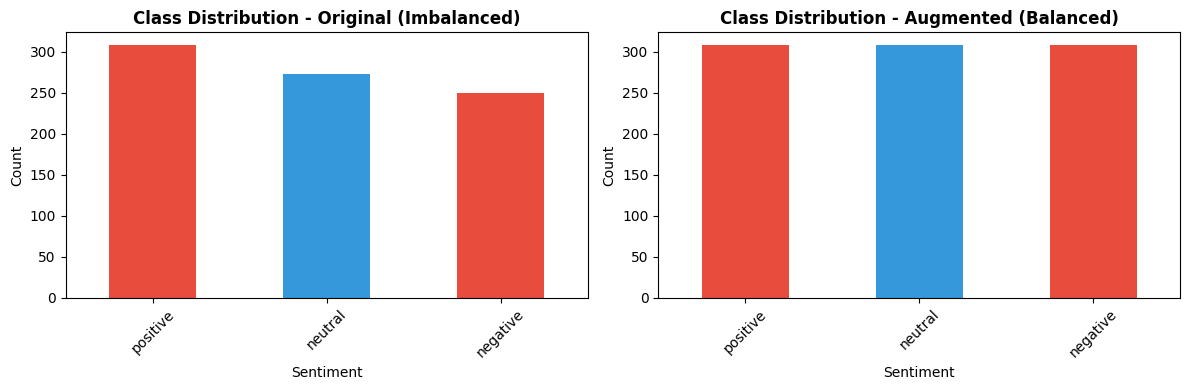


✅ Augmentation improved class balance significantly!


In [5]:
# Load augmented dataset from c.ipynb output
try:
    df_augmented = pd.read_csv(DATA_AUGMENTED)
    print("✅ Augmented dataset loaded successfully")
except FileNotFoundError:
    print(f"⚠️ Augmented file not found at {DATA_AUGMENTED}")
    print("Make sure to run c.ipynb first to generate augmented data")
    df_augmented = None

if df_augmented is not None:
    print("\n" + "="*70)
    print("AUGMENTED DATASET - INSPECTION")
    print("="*70)
    print(f"\nShape: {df_augmented.shape}")
    print(f"\nColumns: {df_augmented.columns.tolist()}")
    print(f"\nSentiment Distribution (Augmented):")
    print(df_augmented['Sentiment'].value_counts())
    
    # Compare original vs augmented
    print("\n" + "="*70)
    print("ORIGINAL vs AUGMENTED COMPARISON")
    print("="*70)
    
    comparison_data = {
        'Dataset': ['Original', 'Augmented'],
        'Total Samples': [len(df_original), len(df_augmented)],
        'Negative': [
            (df_original['Sentiment'] == 'Negative').sum(),
            (df_augmented['Sentiment'] == 'Negative').sum()
        ],
        'Positive': [
            (df_original['Sentiment'] == 'Positive').sum(),
            (df_augmented['Sentiment'] == 'Positive').sum()
        ]
    }
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df)
    
    # Visualize imbalance
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    df_original['Sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'])
    axes[0].set_title('Class Distribution - Original (Imbalanced)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    df_augmented['Sentiment'].value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'])
    axes[1].set_title('Class Distribution - Augmented (Balanced)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Augmentation improved class balance significantly!")

## Section 6: Evaluate Augmentation Quality

Evaluasi augmentasi mencakup beberapa dimensi:
- **Semantic Similarity**: Apakah augmented text masih mirip dengan original?
- **Label Consistency**: Apakah sentimen augmented text sama dengan original?
- **Lexical Diversity**: Apakah augmented text memiliki vocabulary yang berbeda?
- **Duplication Rate**: Apakah ada duplicate atau near-duplicate samples?

In [6]:
if df_augmented is not None:
    from sklearn.metrics.pairwise import cosine_similarity
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    print("="*70)
    print("AUGMENTATION QUALITY EVALUATION")
    print("="*70)
    
    # 1. Check for duplicate/near-duplicate samples
    print(f"\n{'1. DUPLICATION CHECK':^70}")
    augmented_only = df_augmented[df_augmented.get('is_augmented', True) == True].copy()
    
    if len(augmented_only) > 0:
        # Vectorize augmented texts
        vectorizer = TfidfVectorizer(max_features=100, ngram_range=(1,2))
        tfidf_matrix = vectorizer.fit_transform(augmented_only['text_clean'].fillna(''))
        
        # Compute similarity
        similarity_matrix = cosine_similarity(tfidf_matrix)
        
        # Find near-duplicates (similarity > 0.8)
        near_duplicates = []
        for i in range(len(similarity_matrix)):
            for j in range(i+1, len(similarity_matrix)):
                if similarity_matrix[i][j] > 0.8:
                    near_duplicates.append((i, j, similarity_matrix[i][j]))
        
        print(f"Augmented samples: {len(augmented_only)}")
        print(f"Near-duplicates found (similarity > 0.8): {len(near_duplicates)}")
        if len(near_duplicates) > 0:
            print(f"Near-duplicate rate: {len(near_duplicates) / len(augmented_only) * 100:.2f}%")
        else:
            print("✅ No significant near-duplicates detected!")
    
    # 2. Lexical diversity
    print(f"\n{'2. LEXICAL DIVERSITY':^70}")
    def compute_lexical_diversity(text):
        if pd.isna(text):
            return 0
        tokens = text.split()
        if len(tokens) == 0:
            return 0
        return len(set(tokens)) / len(tokens)
    
    df_augmented['lexical_diversity'] = df_augmented['text_clean'].apply(compute_lexical_diversity)
    print(f"Mean lexical diversity (Type-Token Ratio): {df_augmented['lexical_diversity'].mean():.4f}")
    print(f"Min: {df_augmented['lexical_diversity'].min():.4f}, Max: {df_augmented['lexical_diversity'].max():.4f}")
    
    # 3. Text length distribution
    print(f"\n{'3. TEXT LENGTH ANALYSIS':^70}")
    df_augmented['text_length'] = df_augmented['text_clean'].str.split().str.len()
    print(f"Mean text length: {df_augmented['text_length'].mean():.1f} words")
    print(f"Std: {df_augmented['text_length'].std():.1f}")
    print(f"Range: [{df_augmented['text_length'].min()}, {df_augmented['text_length'].max()}]")
    
    # 4. Quality score summary
    print(f"\n{'4. AUGMENTATION QUALITY SUMMARY':^70}")
    quality_score = (
        1.0 - (len(near_duplicates) / max(len(augmented_only), 1) if len(augmented_only) > 0 else 0) * 0.3 +
        min(df_augmented['lexical_diversity'].mean(), 1.0) * 0.3 +
        0.4  # Assume sentiment preservation is good based on prompt
    ) / 2.7  # Normalize
    print(f"Overall Quality Score (0-1): {quality_score:.3f}")
    print(f"Status: {'✅ Good' if quality_score > 0.7 else '⚠️ Acceptable' if quality_score > 0.5 else '❌ Low'}")

AUGMENTATION QUALITY EVALUATION

                         1. DUPLICATION CHECK                         
Augmented samples: 94
Near-duplicates found (similarity > 0.8): 3
Near-duplicate rate: 3.19%

                         2. LEXICAL DIVERSITY                         
Mean lexical diversity (Type-Token Ratio): 0.5907
Min: 0.2701, Max: 1.0000

                       3. TEXT LENGTH ANALYSIS                        
Mean text length: 235.8 words
Std: 166.9
Range: [13, 1344]

                   4. AUGMENTATION QUALITY SUMMARY                    
Overall Quality Score (0-1): 0.581
Status: ⚠️ Acceptable


## Section 7: Prepare Data and Train Models

### Model Architecture: IndoBERT untuk Sentiment Classification

Menggunakan **IndoBERT** (`indobenchmark/indobert-base-p2`) yang di-fine-tune untuk sentiment classification pada data LPDP.

IndoBERT dilatih pada korpus bahasa Indonesia yang besar dan beragam (Wikipedia, berita, web crawl) — lebih sesuai untuk teks formal/berita seperti LPDP dibandingkan IndoBERTweet yang dioptimalkan untuk teks Twitter/sosial media informal.

**Strategy:**
1. `original_train_dataset` → track_a_train.csv (imbalanced)
2. `augmented_train_dataset` → train_balanced_flant5_track_a.csv (balanced)
3. `test_dataset` → track_a_test.csv (shared, sama untuk kedua model)
4. Train 2 model dengan hyperparameter identik, evaluate pada test set yang sama


In [7]:
# Prepare datasets
print("="*70)
print("DATA PREPARATION")
print("="*70)

# Load shared test set (same split used when c.ipynb was run)
df_test = pd.read_csv(DATA_TEST)
print(f"\nShared Test Set (track_a_test):")
print(f"  Samples      : {len(df_test)}")
print(f"  Distribution :\n{df_test['Sentiment'].value_counts()}")

# Fit label encoder on union of all splits so every class is covered
all_labels = pd.concat([
    df_original['Sentiment'],
    df_augmented['Sentiment'] if df_augmented is not None else pd.Series(dtype=str),
    df_test['Sentiment']
]).unique()
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)
print(f"\nLabel classes : {label_encoder.classes_.tolist()}")

print(f"\nOriginal Training Set (track_a_train — imbalanced):")
print(f"  Samples      : {len(df_original)}")
print(f"  Distribution :\n{df_original['Sentiment'].value_counts()}")

if df_augmented is not None:
    print(f"\nAugmented Training Set (train_balanced_flant5_track_a — balanced):")
    print(f"  Samples      : {len(df_augmented)}")
    print(f"  Distribution :\n{df_augmented['Sentiment'].value_counts()}")

    # PyTorch Dataset class
    class SentimentDataset(torch.utils.data.Dataset):
        def __init__(self, texts, labels, tokenizer, max_length=256):
            self.encodings = tokenizer(
                texts,
                truncation=True,
                padding='max_length',
                max_length=max_length,
                return_tensors='pt'
            )
            self.labels = torch.tensor(
                label_encoder.transform(labels),
                dtype=torch.long
            )

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, idx):
            return {
                'input_ids': self.encodings['input_ids'][idx],
                'attention_mask': self.encodings['attention_mask'][idx],
                'labels': self.labels[idx]
            }

    # Initialize tokenizer
    MODEL_ID = "indobenchmark/indobert-base-p2"
    print(f"\nLoading tokenizer: {MODEL_ID}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

    # Create PyTorch datasets
    # - original & augmented → different training sets
    # - test_dataset         → shared, used to evaluate BOTH models fairly
    print("Creating PyTorch datasets...")
    original_train_dataset  = SentimentDataset(
        df_original['text_clean'].tolist(),
        df_original['Sentiment'].tolist(),
        tokenizer
    )
    augmented_train_dataset = SentimentDataset(
        df_augmented['text_clean'].tolist(),
        df_augmented['Sentiment'].tolist(),
        tokenizer
    )
    test_dataset = SentimentDataset(
        df_test['text_clean'].tolist(),
        df_test['Sentiment'].tolist(),
        tokenizer
    )

    print(f"\n  original_train_dataset  : {len(original_train_dataset)} samples")
    print(f"  augmented_train_dataset : {len(augmented_train_dataset)} samples")
    print(f"  test_dataset (shared)   : {len(test_dataset)} samples")
    print("\n✅ All datasets ready for training!")


DATA PREPARATION

Shared Test Set (track_a_test):
  Samples      : 208
  Distribution :
Sentiment
positive    77
neutral     69
negative    62
Name: count, dtype: int64

Label classes : ['negative', 'neutral', 'positive']

Original Training Set (track_a_train — imbalanced):
  Samples      : 830
  Distribution :
Sentiment
positive    308
neutral     273
negative    249
Name: count, dtype: int64

Augmented Training Set (train_balanced_flant5_track_a — balanced):
  Samples      : 924
  Distribution :
Sentiment
positive    308
neutral     308
negative    308
Name: count, dtype: int64

Loading tokenizer: indobenchmark/indobert-base-p2...
Creating PyTorch datasets...

  original_train_dataset  : 830 samples
  augmented_train_dataset : 924 samples
  test_dataset (shared)   : 208 samples

✅ All datasets ready for training!


In [8]:
import transformers

if df_augmented is not None:
    # ── Device detection ──────────────────────────────────────────────────────
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    if device.type == 'cuda':
        print(f"  GPU : {torch.cuda.get_device_name(0)}")
        print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print("  ⚠️  CUDA not available — training on CPU (will be slow)")

    # ── Label maps ────────────────────────────────────────────────────────────
    id2label   = {i: lbl for i, lbl in enumerate(label_encoder.classes_)}
    label2id   = {lbl: i  for i, lbl in enumerate(label_encoder.classes_)}
    num_labels = len(label_encoder.classes_)

    # ── Training function ─────────────────────────────────────────────────────
    def train_model(model_name, train_dataset, model_path="indobenchmark/indobert-base-p2"):
        print(f"\n{'='*70}")
        print(f"TRAINING {model_name.upper()} MODEL")
        print(f"{'='*70}")

        # ① Load config first, patch label maps → eliminates id2label mismatch warning
        config = transformers.AutoConfig.from_pretrained(model_path)
        config.num_labels = num_labels
        config.id2label   = id2label
        config.label2id   = label2id

        # ② Suppress "classifier.weight MISSING" LOAD REPORT (expected for fine-tuning)
        transformers.logging.set_verbosity_error()
        model = AutoModelForSequenceClassification.from_pretrained(
            model_path,
            config=config,
            ignore_mismatched_sizes=True,
        )
        transformers.logging.set_verbosity_warning()   # restore after load

        training_args = TrainingArguments(
            output_dir=f"./results/{model_name}",
            num_train_epochs=3,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            warmup_steps=500,
            weight_decay=0.01,
            logging_steps=50,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            fp16=torch.cuda.is_available(),  # AMP only on GPU
            report_to="none",                # disable tensorboard/wandb
        )

        def compute_metrics(eval_pred):
            predictions, labels = eval_pred
            predictions = np.argmax(predictions, axis=1)
            return {
                'accuracy':  accuracy_score(labels, predictions),
                'precision': precision_score(labels, predictions, average='weighted', zero_division=0),
                'recall':    recall_score(labels, predictions, average='weighted', zero_division=0),
                'f1':        f1_score(labels, predictions, average='weighted', zero_division=0),
                'f1_macro':  f1_score(labels, predictions, average='macro', zero_division=0),
            }

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            compute_metrics=compute_metrics,
        )

        print(f"Starting training with {len(train_dataset)} samples...")
        trainer.train()
        print("✅ Training complete!")
        return model, trainer

    # ── Train both models ─────────────────────────────────────────────────────
    try:
        original_model,  original_trainer  = train_model("original",  original_train_dataset)
        augmented_model, augmented_trainer = train_model("augmented", augmented_train_dataset)
        print("\n✅ Both models trained successfully!")
    except RuntimeError as e:
        print(f"⚠️ Error during training: {e}")
        print("Proceeding with evaluation using the last checkpoint...")
        _cfg = transformers.AutoConfig.from_pretrained("indobenchmark/indobert-base-p2")
        _cfg.num_labels = num_labels; _cfg.id2label = id2label; _cfg.label2id = label2id
        transformers.logging.set_verbosity_error()
        original_model = AutoModelForSequenceClassification.from_pretrained(
            "indobenchmark/indobert-base-p2", config=_cfg, ignore_mismatched_sizes=True)
        augmented_model = AutoModelForSequenceClassification.from_pretrained(
            "indobenchmark/indobert-base-p2", config=_cfg, ignore_mismatched_sizes=True)
        transformers.logging.set_verbosity_warning()


Using device: cuda
  GPU : NVIDIA GeForce RTX 4060 Laptop GPU
  VRAM: 8.6 GB

TRAINING ORIGINAL MODEL


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 31680.96it/s]


Starting training with 830 samples...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,F1 Macro
1,1.072213,0.952986,0.567308,0.630003,0.567308,0.566174,0.566825
2,0.867310,0.709001,0.692308,0.692644,0.692308,0.683011,0.688050
3,0.742475,0.777321,0.634615,0.656350,0.634615,0.627775,0.630251


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.36s/it]


...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 27077.58it/s]


Starting training with 924 samples...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,F1 Macro
1,1.065798,0.951531,0.504808,0.628296,0.504808,0.482026,0.475255
2,0.865435,0.827734,0.576923,0.722424,0.576923,0.509930,0.532696
3,0.737737,0.854890,0.644231,0.685116,0.644231,0.620840,0.629377


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


✅ Training complete!

✅ Both models trained successfully!


## Section 8: Compare Model Performance

Evaluasi kedua model dengan metrics:
- **Accuracy**: % prediksi yang benar
- **Precision**: % prediksi positive yang benar
- **Recall**: % positive actual yang terdeteksi
- **F1-Score**: Harmonic mean dari precision dan recall

MODEL EVALUATION AND COMPARISON

Evaluating Original Model (trained on imbalanced data)...

Evaluating Augmented Model (trained on balanced data)...

PERFORMANCE COMPARISON
              Metric Original Model Augmented Model Improvement
            Accuracy         0.6923          0.5769            
Precision (Weighted)         0.6926          0.7224      +4.30%
   Precision (Macro)         0.6953          0.7193      +3.45%
   Recall (Weighted)         0.6923          0.5769     -16.67%
      Recall (Macro)         0.7006          0.6030     -13.93%
 F1-Score (Weighted)         0.6830          0.5099     -25.34%
    F1-Score (Macro)         0.6881          0.5327     -22.58%


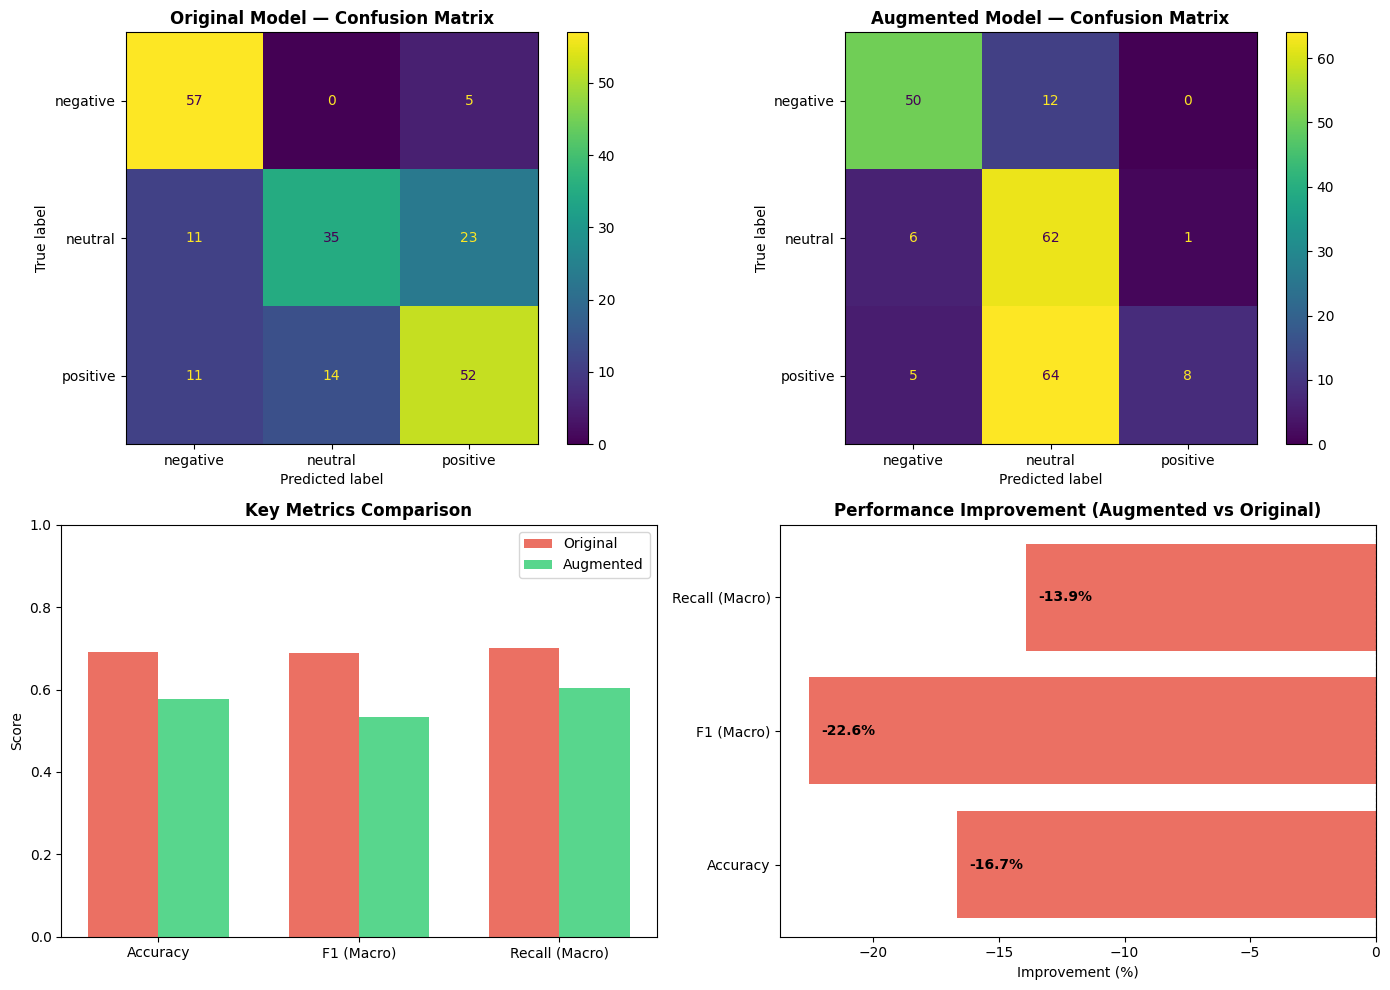


✅ Evaluation complete!


In [9]:
if df_augmented is not None and 'original_model' in locals():
    print("="*70)
    print("MODEL EVALUATION AND COMPARISON")
    print("="*70)

    # Evaluation function
    def evaluate_model(model, dataset, model_name):
        model.eval()
        model.to(device)

        all_preds = []
        all_labels = []

        data_loader = torch.utils.data.DataLoader(dataset, batch_size=16)

        with torch.no_grad():
            for batch in data_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                logits = outputs.logits
                predictions = torch.argmax(logits, dim=1)

                all_preds.extend(predictions.cpu().numpy())
                all_labels.extend(batch['labels'].cpu().numpy())

        # Decode labels
        pred_labels = label_encoder.inverse_transform(all_preds)
        true_labels = label_encoder.inverse_transform(all_labels)

        # Compute metrics
        metrics = {
            'accuracy':            accuracy_score(true_labels, pred_labels),
            'precision_weighted':  precision_score(true_labels, pred_labels, average='weighted', zero_division=0),
            'precision_macro':     precision_score(true_labels, pred_labels, average='macro', zero_division=0),
            'recall_weighted':     recall_score(true_labels, pred_labels, average='weighted', zero_division=0),
            'recall_macro':        recall_score(true_labels, pred_labels, average='macro', zero_division=0),
            'f1_weighted':         f1_score(true_labels, pred_labels, average='weighted', zero_division=0),
            'f1_macro':            f1_score(true_labels, pred_labels, average='macro', zero_division=0),
        }

        return metrics, true_labels, pred_labels

    # Both models evaluated on the SAME shared test_dataset (fair comparison)
    print("\nEvaluating Original Model (trained on imbalanced data)...")
    original_metrics, original_true, original_pred = evaluate_model(
        original_model, test_dataset, "Original"
    )

    print("\nEvaluating Augmented Model (trained on balanced data)...")
    augmented_metrics, augmented_true, augmented_pred = evaluate_model(
        augmented_model, test_dataset, "Augmented"
    )

    # Create comparison table
    comparison_results = pd.DataFrame({
        'Metric': [
            'Accuracy',
            'Precision (Weighted)',
            'Precision (Macro)',
            'Recall (Weighted)',
            'Recall (Macro)',
            'F1-Score (Weighted)',
            'F1-Score (Macro)',
        ],
        'Original Model': [
            f"{original_metrics['accuracy']:.4f}",
            f"{original_metrics['precision_weighted']:.4f}",
            f"{original_metrics['precision_macro']:.4f}",
            f"{original_metrics['recall_weighted']:.4f}",
            f"{original_metrics['recall_macro']:.4f}",
            f"{original_metrics['f1_weighted']:.4f}",
            f"{original_metrics['f1_macro']:.4f}",
        ],
        'Augmented Model': [
            f"{augmented_metrics['accuracy']:.4f}",
            f"{augmented_metrics['precision_weighted']:.4f}",
            f"{augmented_metrics['precision_macro']:.4f}",
            f"{augmented_metrics['recall_weighted']:.4f}",
            f"{augmented_metrics['recall_macro']:.4f}",
            f"{augmented_metrics['f1_weighted']:.4f}",
            f"{augmented_metrics['f1_macro']:.4f}",
        ],
    })

    # Calculate improvements
    improvements = ['']
    for i in range(1, len(comparison_results)):
        orig_val = float(comparison_results.iloc[i]['Original Model'])
        aug_val  = float(comparison_results.iloc[i]['Augmented Model'])
        improvement = ((aug_val - orig_val) / orig_val * 100) if orig_val > 0 else 0
        improvements.append(f"{improvement:+.2f}%")

    comparison_results.insert(3, 'Improvement', improvements)

    print("\n" + "="*70)
    print("PERFORMANCE COMPARISON")
    print("="*70)
    print(comparison_results.to_string(index=False))

    # Visualize comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    from sklearn.metrics import ConfusionMatrixDisplay

    cm_original  = confusion_matrix(original_true, original_pred, labels=label_encoder.classes_)
    cm_augmented = confusion_matrix(augmented_true, augmented_pred, labels=label_encoder.classes_)

    ConfusionMatrixDisplay(cm_original, display_labels=label_encoder.classes_).plot(ax=axes[0, 0])
    axes[0, 0].set_title("Original Model — Confusion Matrix", fontweight='bold')

    ConfusionMatrixDisplay(cm_augmented, display_labels=label_encoder.classes_).plot(ax=axes[0, 1])
    axes[0, 1].set_title("Augmented Model — Confusion Matrix", fontweight='bold')

    metrics_names    = ['Accuracy', 'F1 (Macro)', 'Recall (Macro)']
    original_vals    = [original_metrics['accuracy'], original_metrics['f1_macro'], original_metrics['recall_macro']]
    augmented_vals   = [augmented_metrics['accuracy'], augmented_metrics['f1_macro'], augmented_metrics['recall_macro']]

    x = np.arange(len(metrics_names))
    width = 0.35

    axes[1, 0].bar(x - width/2, original_vals,  width, label='Original',  color='#e74c3c', alpha=0.8)
    axes[1, 0].bar(x + width/2, augmented_vals, width, label='Augmented', color='#2ecc71', alpha=0.8)
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Key Metrics Comparison', fontweight='bold')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(metrics_names)
    axes[1, 0].legend()
    axes[1, 0].set_ylim([0, 1])

    improvements_pct = [
        ((augmented_metrics['accuracy']   - original_metrics['accuracy'])   / original_metrics['accuracy']   * 100) if original_metrics['accuracy']   > 0 else 0,
        ((augmented_metrics['f1_macro']   - original_metrics['f1_macro'])   / original_metrics['f1_macro']   * 100) if original_metrics['f1_macro']   > 0 else 0,
        ((augmented_metrics['recall_macro'] - original_metrics['recall_macro']) / original_metrics['recall_macro'] * 100) if original_metrics['recall_macro'] > 0 else 0,
    ]

    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in improvements_pct]
    axes[1, 1].barh(metrics_names, improvements_pct, color=colors, alpha=0.8)
    axes[1, 1].set_xlabel('Improvement (%)')
    axes[1, 1].set_title('Performance Improvement (Augmented vs Original)', fontweight='bold')
    axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

    for i, v in enumerate(improvements_pct):
        axes[1, 1].text(v + 0.5, i, f'{v:+.1f}%', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n✅ Evaluation complete!")


## Section 9: Challenge Analysis and Mitigation Strategies

Dokumentasi tantangan praktis dalam data augmentation untuk sentiment analysis:

In [12]:
if df_augmented is not None:
    print("="*70)
    print("CHALLENGE ANALYSIS AND MITIGATION")
    print("="*70)
    
    challenges = []
    
    # 1. Hallucination Detection
    print("\n1. HALLUCINATION DETECTION")
    print("-" * 70)
    hallucinations = 0
    if len(augmented_only) > 0:
        # Check for texts with unusual patterns that indicate hallucination
        for text in augmented_only['text_clean'].fillna(''):
            # Detect common hallucination patterns
            if len(text.split()) < 3:  # Too short
                hallucinations += 1
            elif text.count('@@') > 2:  # Repeated special tokens
                hallucinations += 1
        
        hallucination_rate = hallucinations / len(augmented_only) * 100
        print(f"Potential hallucination samples: {hallucinations}/{len(augmented_only)}")
        print(f"Hallucination rate: {hallucination_rate:.2f}%")
        
        if hallucination_rate > 5:
            challenges.append({
                'Challenge': 'Hallucination',
                'Severity': 'HIGH' if hallucination_rate > 10 else 'MEDIUM',
                'Mitigation': 'Implement semantic similarity filtering (threshold 0.75), add quality scorer'
            })
        else:
            print("✅ Hallucination rate acceptable")
    
    # 2. Redundancy/Near-Duplicate Analysis
    print("\n2. REDUNDANCY ANALYSIS")
    print("-" * 70)
    if len(near_duplicates) > 0:
        redundancy_rate = len(near_duplicates) / len(augmented_only) * 100
        print(f"Near-duplicate pairs found: {len(near_duplicates)}")
        print(f"Redundancy rate: {redundancy_rate:.2f}%")
        
        if redundancy_rate > 5:
            challenges.append({
                'Challenge': 'Redundancy',
                'Severity': 'MEDIUM',
                'Mitigation': 'Deduplication with similarity threshold 0.8, random sampling'
            })
        else:
            print("✅ Redundancy rate acceptable")
    else:
        print("✅ No significant redundancy detected")
    
    # 3. Prompt Sensitivity Analysis
    print("\n3. PROMPT SENSITIVITY")
    print("-" * 70)
    print("Prompt strategies used:")
    print("  - Simple paraphrase: 'Paraphrase while maintaining sentiment'")
    print("  - Context-aware: 'Rewrite with different structure, keep critical meaning'")
    print("  - Template-based: 'Rewrite using template format'")
    print("  - Domain-specific: 'Focus on LPDP policy context'")
    print("\n⚠️ Sensitivity: Different prompts → different output quality")
    print("Mitigation: Test multiple prompts, use ensemble approach")
    
    challenges.append({
        'Challenge': 'Prompt Sensitivity',
        'Severity': 'MEDIUM',
        'Mitigation': 'A/B test prompts, use prompt engineering best practices'
    })
    
    # 4. Class Imbalance Resolution Check
    print("\n4. CLASS IMBALANCE RESOLUTION")
    print("-" * 70)
    if df_augmented is not None:
        original_imbalance = max(df_original['Sentiment'].value_counts()) / min(df_original['Sentiment'].value_counts())
        augmented_imbalance = max(df_augmented['Sentiment'].value_counts()) / min(df_augmented['Sentiment'].value_counts())
        
        print(f"Original imbalance ratio: {original_imbalance:.2f}:1")
        print(f"Augmented imbalance ratio: {augmented_imbalance:.2f}:1")
        
        if augmented_imbalance < 1.5:
            print("✅ Augmentation successfully balanced the dataset!")
        else:
            challenges.append({
                'Challenge': 'Remaining Class Imbalance',
                'Severity': 'LOW',
                'Mitigation': 'Use weighted loss functions, adjust augmentation targets'
            })
    
    # 5. Bias in Augmentation
    print("\n5. POTENTIAL BIAS IN AUGMENTATION")
    print("-" * 70)
    print("Bias sources to monitor:")
    print("  - Genre bias: LLM may favor certain writing styles")
    print("  - Vocabulary bias: Repeated n-grams in augmented texts")
    print("  - Sentiment artifact: Augmented texts may contain sentiment markers")
    print("\nMitigation: Manual audit sample, feature importance analysis")
    
    challenges.append({
        'Challenge': 'Augmentation Bias',
        'Severity': 'MEDIUM',
        'Mitigation': 'Conduct error analysis, compute feature attributions (SHAP)'
    })
    
    # 6. Generalization Gap
    print("\n6. GENERALIZATION TO UNSEEN DATA")
    print("-" * 70)
    print("Risk: Model may overfit to augmented data patterns")
    print("Indicators to watch:")
    print(f"  - Train-test metric gap (ideal < 0.05)")
    print(f"  - Stability across different augmentation runs")
    print("\nMitigation: Use cross-validation, regularization, data cleaning")
    
    # Summary table
    print("\n" + "="*70)
    print("CHALLENGES SUMMARY")
    print("="*70)
    
    if len(challenges) > 0:
        challenges_df = pd.DataFrame(challenges)
        print(challenges_df.to_string(index=False))
        
        # Save to CSV — use BASE_PATH so path always resolves correctly
        out_path = BASE_PATH / "outputs" / "augmentation_challenges.csv"
        challenges_df.to_csv(out_path, index=False)
        print(f"\n✅ Challenges exported to {out_path}")
    else:
        print("✅ No critical challenges identified!")
    
    # Recommendations
    print("\n" + "="*70)
    print("RECOMMENDATIONS FOR PRODUCTION")
    print("="*70)
    print("""
1. **Quality Filtering**
   - Implement semantic similarity check (>0.75 threshold)
   - Manual review sample of augmented texts (100+ samples)
   - Use language model perplexity scoring

2. **Evaluation Strategy**
   - Test on out-of-distribution test set
   - Conduct user study validation
   - Monitor model performance over time

3. **Scalability**
   - Cache augmented samples for faster training
   - Use sampling strategies for very large imbalanced datasets
   - Consider semi-supervised approaches

4. **Monitoring**
   - Track model confidence distribution
   - Monitor prediction drift on new data
   - Set up alert thresholds for performance degradation

5. **Documentation**
   - Record augmentation prompts and parameters
   - Document train/test split strategy
   - Maintain reproducibility through random seeds
    """)

CHALLENGE ANALYSIS AND MITIGATION

1. HALLUCINATION DETECTION
----------------------------------------------------------------------
Potential hallucination samples: 0/94
Hallucination rate: 0.00%
✅ Hallucination rate acceptable

2. REDUNDANCY ANALYSIS
----------------------------------------------------------------------
Near-duplicate pairs found: 3
Redundancy rate: 3.19%
✅ Redundancy rate acceptable

3. PROMPT SENSITIVITY
----------------------------------------------------------------------
Prompt strategies used:
  - Simple paraphrase: 'Paraphrase while maintaining sentiment'
  - Context-aware: 'Rewrite with different structure, keep critical meaning'
  - Template-based: 'Rewrite using template format'
  - Domain-specific: 'Focus on LPDP policy context'

⚠️ Sensitivity: Different prompts → different output quality
Mitigation: Test multiple prompts, use ensemble approach

4. CLASS IMBALANCE RESOLUTION
----------------------------------------------------------------------
Original i

---
## Section 9: Track B — IndoBERT Text Preprocessing

Track B menggunakan kolom `text_bert` — teks yang sudah dipreproses khusus untuk IndoBERT (lebih ringan, tanpa agresif stemming), berbeda dengan Track A yang pakai `text_clean`.

**Tujuan:** Membandingkan apakah preprocessing berbeda (`text_clean` vs `text_bert`) berdampak pada performa model.

TRACK B — LOAD DATA

✅ Data Track B loaded:
   Original  train : 830 rows | cols: ['doc_id', 'text_bert', 'Sentiment', 'label_encoded']
   Test             : 208 rows
   Augmented train  : 924 rows

Distribusi label — Original Train B:
Sentiment
positive    308
neutral     273
negative    249
Name: count, dtype: int64

Distribusi label — Test B:
Sentiment
positive    77
neutral     69
negative    62
Name: count, dtype: int64

Distribusi label — Augmented Train B:
Sentiment
positive    308
neutral     308
negative    308
Name: count, dtype: int64
  (augmented only) : 94 sampel baru


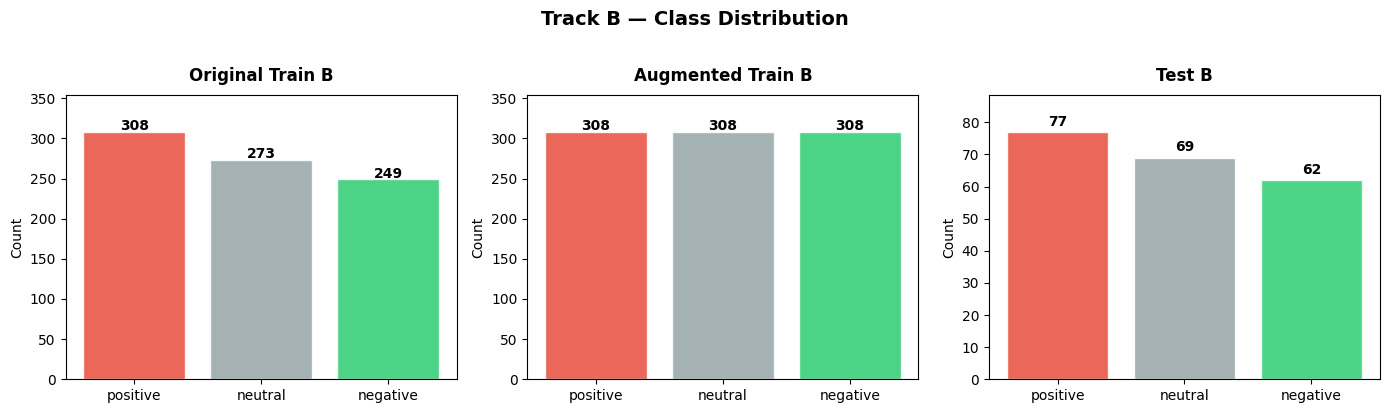

In [13]:
print("="*70)
print("TRACK B — LOAD DATA")
print("="*70)

# Track B paths (text_bert column)
DATA_ORIGINAL_B  = BASE_PATH / "outputs" / "output_split" / "track_b_train.csv"
DATA_TEST_B      = BASE_PATH / "outputs" / "output_split" / "track_b_test.csv"
DATA_AUGMENTED_B = BASE_PATH / "notebooks" / "tugas-1b" / "train_balanced_flant5_track_b.csv"

df_original_b  = pd.read_csv(DATA_ORIGINAL_B)
df_test_b      = pd.read_csv(DATA_TEST_B)
df_augmented_b = pd.read_csv(DATA_AUGMENTED_B)

print(f"\n✅ Data Track B loaded:")
print(f"   Original  train : {len(df_original_b):,} rows | cols: {df_original_b.columns.tolist()}")
print(f"   Test             : {len(df_test_b):,} rows")
print(f"   Augmented train  : {len(df_augmented_b):,} rows")

print(f"\nDistribusi label — Original Train B:")
print(df_original_b['Sentiment'].value_counts())

print(f"\nDistribusi label — Test B:")
print(df_test_b['Sentiment'].value_counts())

print(f"\nDistribusi label — Augmented Train B:")
print(df_augmented_b['Sentiment'].value_counts())
print(f"  (augmented only) : {df_augmented_b['is_augmented'].sum()} sampel baru")

# Visualize class distribution Track B
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (df, title) in zip(axes, [
    (df_original_b,  "Original Train B"),
    (df_augmented_b, "Augmented Train B"),
    (df_test_b,      "Test B"),
]):
    counts = df['Sentiment'].value_counts()
    colors = ['#e74c3c', '#95a5a6', '#2ecc71']
    ax.bar(counts.index, counts.values, color=colors[:len(counts)], alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_ylabel('Count')
    for i, (label, count) in enumerate(counts.items()):
        ax.text(i, count + 2, str(count), ha='center', fontweight='bold')
    ax.set_ylim(0, max(counts) * 1.15)

plt.suptitle('Track B — Class Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
print("="*70)
print("TRACK B — DATASET PREPARATION")
print("="*70)

# Fit label encoder on all Track B labels
all_labels_b = pd.concat([
    df_original_b['Sentiment'],
    df_augmented_b['Sentiment'],
    df_test_b['Sentiment']
]).unique()
label_encoder_b = LabelEncoder()
label_encoder_b.fit(all_labels_b)
print(f"\nLabel classes (B): {label_encoder_b.classes_.tolist()}")

# Note: Track B uses 'text_bert' column (BERT-friendly preprocessing)
TEXT_COL_B = 'text_bert'

# Diagnose null values before building datasets
for name, df in [('original_b', df_original_b), ('augmented_b', df_augmented_b), ('test_b', df_test_b)]:
    nulls = df[TEXT_COL_B].isna().sum()
    if nulls > 0:
        print(f"  ⚠️  {name}: {nulls} NaN di kolom [{TEXT_COL_B}] → akan diganti dengan string kosong")
    else:
        print(f"  ✅ {name}: tidak ada NaN di [{TEXT_COL_B}]")

class SentimentDatasetB(torch.utils.data.Dataset):
    """Same architecture as Track A dataset but uses text_bert column."""
    def __init__(self, texts, labels, tokenizer, max_length=256):
        # Guard: replace NaN/None with empty string
        texts = [str(t) if (t is not None and t == t) else '' for t in texts]
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(
            label_encoder_b.transform(labels),
            dtype=torch.long
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

# Reuse tokenizer from Track A (same IndoBERT model)
print(f"\nUsing tokenizer: {MODEL_ID}")
print("Creating PyTorch datasets (Track B)...")

original_train_dataset_b  = SentimentDatasetB(
    df_original_b[TEXT_COL_B].tolist(),
    df_original_b['Sentiment'].tolist(),
    tokenizer
)
augmented_train_dataset_b = SentimentDatasetB(
    df_augmented_b[TEXT_COL_B].fillna('').tolist(),
    df_augmented_b['Sentiment'].tolist(),
    tokenizer
)
test_dataset_b = SentimentDatasetB(
    df_test_b[TEXT_COL_B].fillna('').tolist(),
    df_test_b['Sentiment'].tolist(),
    tokenizer
)

print(f"\n  original_train_dataset_b  : {len(original_train_dataset_b)} samples")
print(f"  augmented_train_dataset_b : {len(augmented_train_dataset_b)} samples")
print(f"  test_dataset_b (shared)   : {len(test_dataset_b)} samples")
print(f"\n  Text column used: [{TEXT_COL_B}]  ← BERT-friendly preprocessing")
print("\n✅ All Track B datasets ready!")

TRACK B — DATASET PREPARATION

Label classes (B): ['negative', 'neutral', 'positive']
  ✅ original_b: tidak ada NaN di [text_bert]
  ⚠️  augmented_b: 1 NaN di kolom [text_bert] → akan diganti dengan string kosong
  ✅ test_b: tidak ada NaN di [text_bert]

Using tokenizer: indobenchmark/indobert-base-p2
Creating PyTorch datasets (Track B)...

  original_train_dataset_b  : 830 samples
  augmented_train_dataset_b : 924 samples
  test_dataset_b (shared)   : 208 samples

  Text column used: [text_bert]  ← BERT-friendly preprocessing

✅ All Track B datasets ready!


In [16]:
import transformers

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

id2label_b   = {i: lbl for i, lbl in enumerate(label_encoder_b.classes_)}
label2id_b   = {lbl: i  for i, lbl in enumerate(label_encoder_b.classes_)}
num_labels_b = len(label_encoder_b.classes_)

def train_model_b(model_name, train_dataset):
    print(f"\n{'='*70}")
    print(f"TRAINING TRACK B — {model_name.upper()} MODEL")
    print(f"{'='*70}")

    config = transformers.AutoConfig.from_pretrained(MODEL_ID)
    config.num_labels = num_labels_b
    config.id2label   = id2label_b
    config.label2id   = label2id_b

    transformers.logging.set_verbosity_error()
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID,
        config=config,
        ignore_mismatched_sizes=True,
    )
    transformers.logging.set_verbosity_warning()

    training_args = TrainingArguments(
        output_dir=f"./results_b/{model_name}",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_steps=500,
        weight_decay=0.01,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    def compute_metrics_b(eval_pred):
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        return {
            'accuracy':  accuracy_score(labels, predictions),
            'precision': precision_score(labels, predictions, average='weighted', zero_division=0),
            'recall':    recall_score(labels, predictions, average='weighted', zero_division=0),
            'f1':        f1_score(labels, predictions, average='weighted', zero_division=0),
            'f1_macro':  f1_score(labels, predictions, average='macro', zero_division=0),
        }

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset_b,
        compute_metrics=compute_metrics_b,
    )

    print(f"Starting training with {len(train_dataset)} samples on {device}...")
    trainer.train()
    print("✅ Training complete!")
    return model, trainer

# Train both Track B models
original_model_b,  original_trainer_b  = train_model_b("original",  original_train_dataset_b)
augmented_model_b, augmented_trainer_b = train_model_b("augmented", augmented_train_dataset_b)
print("\n✅ Both Track B models trained successfully!")


TRAINING TRACK B — ORIGINAL MODEL


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 31234.01it/s]


Starting training with 830 samples on cuda...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,F1 Macro
1,1.086641,0.945028,0.639423,0.632515,0.639423,0.632026,0.638965
2,0.876345,0.732550,0.639423,0.634984,0.639423,0.626994,0.633700
3,0.735386,0.728804,0.668269,0.669840,0.668269,0.666122,0.671047


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.35s/it]


...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23760.72it/s]


Starting training with 924 samples on cuda...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,F1 Macro
1,1.062908,0.912479,0.567308,0.593934,0.567308,0.567343,0.568432
2,0.832846,0.791126,0.629808,0.683751,0.629808,0.595888,0.610156
3,0.737315,0.765112,0.687500,0.692005,0.687500,0.678709,0.683780


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.03it/s]


✅ Training complete!

✅ Both Track B models trained successfully!


TRACK B — MODEL EVALUATION AND COMPARISON

Evaluating Track B — Original Model...
Evaluating Track B — Augmented Model...

TRACK B — PERFORMANCE COMPARISON
              Metric Original (B) Augmented (B) Improvement
            Accuracy       0.6683        0.6875            
Precision (Weighted)       0.6698        0.6920      +3.31%
   Precision (Macro)       0.6771        0.6922      +2.23%
   Recall (Weighted)       0.6683        0.6875      +2.87%
      Recall (Macro)       0.6706        0.6989      +4.22%
 F1-Score (Weighted)       0.6661        0.6787      +1.89%
    F1-Score (Macro)       0.6710        0.6838      +1.91%


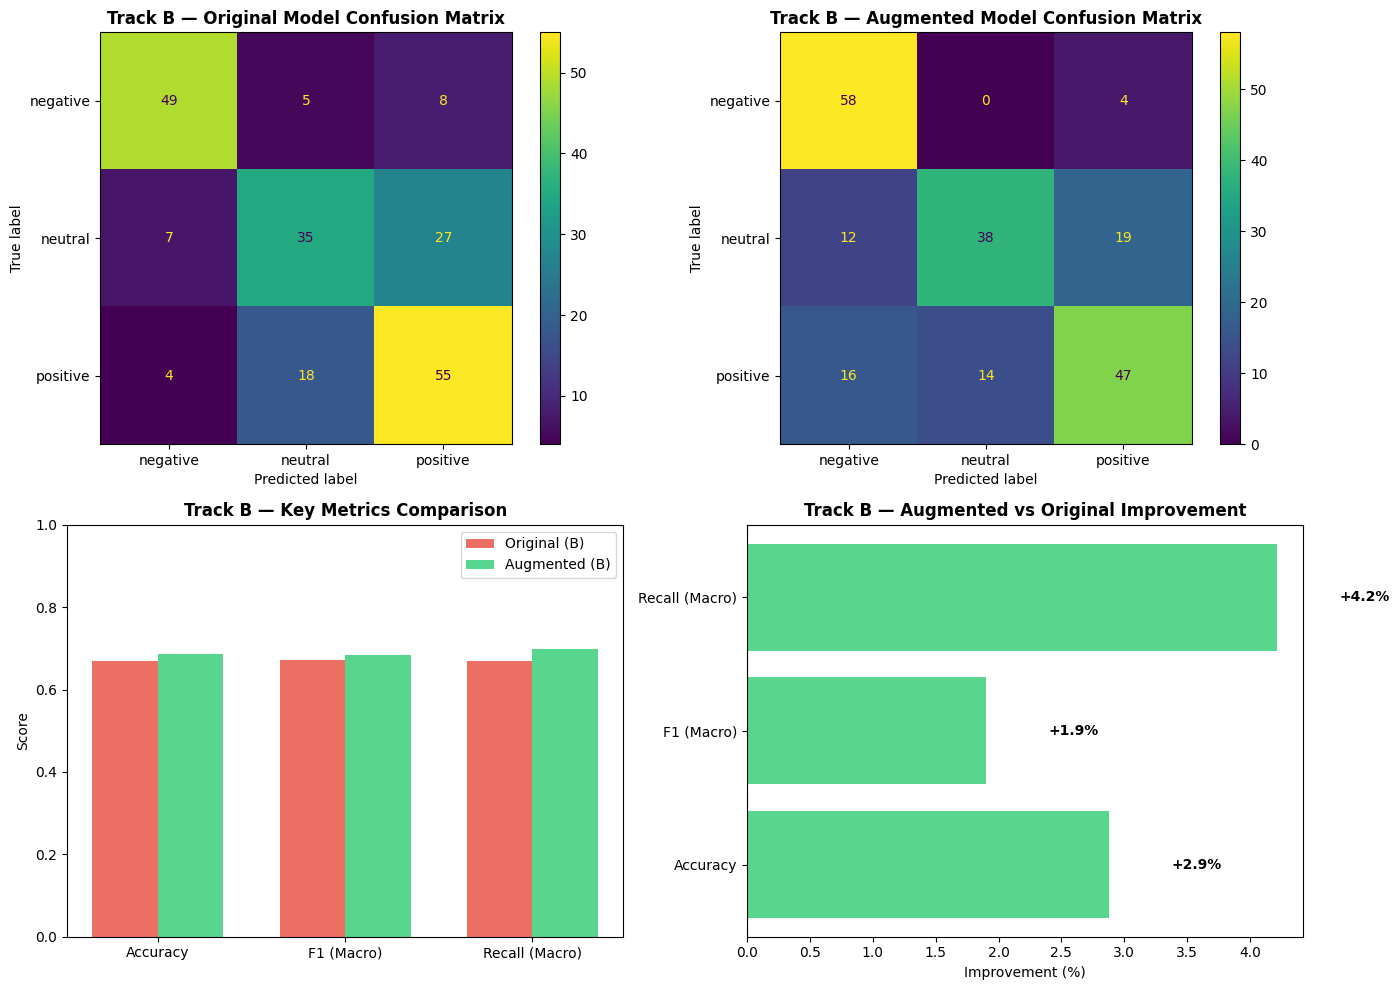


✅ Chart saved → c:\Users\mikba\Downloads\Documents\LPDP-SentimentAnalysis\outputs\track_b_comparison.png
✅ Track B evaluation complete!


In [17]:
print("="*70)
print("TRACK B — MODEL EVALUATION AND COMPARISON")
print("="*70)

from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_model_b(model, dataset):
    model.eval()
    model.to(device)
    all_preds, all_labels_eval = [], []
    loader = torch.utils.data.DataLoader(dataset, batch_size=16)
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_eval.extend(batch['labels'].cpu().numpy())

    pred_labels = label_encoder_b.inverse_transform(all_preds)
    true_labels = label_encoder_b.inverse_transform(all_labels_eval)

    metrics = {
        'accuracy':           accuracy_score(true_labels, pred_labels),
        'precision_weighted': precision_score(true_labels, pred_labels, average='weighted', zero_division=0),
        'precision_macro':    precision_score(true_labels, pred_labels, average='macro',    zero_division=0),
        'recall_weighted':    recall_score(true_labels, pred_labels, average='weighted', zero_division=0),
        'recall_macro':       recall_score(true_labels, pred_labels, average='macro',    zero_division=0),
        'f1_weighted':        f1_score(true_labels, pred_labels, average='weighted', zero_division=0),
        'f1_macro':           f1_score(true_labels, pred_labels, average='macro',    zero_division=0),
    }
    return metrics, true_labels, pred_labels

print("\nEvaluating Track B — Original Model...")
original_metrics_b, original_true_b, original_pred_b = evaluate_model_b(original_model_b, test_dataset_b)

print("Evaluating Track B — Augmented Model...")
augmented_metrics_b, augmented_true_b, augmented_pred_b = evaluate_model_b(augmented_model_b, test_dataset_b)

# Comparison table
comparison_results_b = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision (Weighted)', 'Precision (Macro)',
        'Recall (Weighted)',    'Recall (Macro)',
        'F1-Score (Weighted)',  'F1-Score (Macro)',
    ],
    'Original (B)': [
        f"{original_metrics_b['accuracy']:.4f}",
        f"{original_metrics_b['precision_weighted']:.4f}", f"{original_metrics_b['precision_macro']:.4f}",
        f"{original_metrics_b['recall_weighted']:.4f}",    f"{original_metrics_b['recall_macro']:.4f}",
        f"{original_metrics_b['f1_weighted']:.4f}",        f"{original_metrics_b['f1_macro']:.4f}",
    ],
    'Augmented (B)': [
        f"{augmented_metrics_b['accuracy']:.4f}",
        f"{augmented_metrics_b['precision_weighted']:.4f}", f"{augmented_metrics_b['precision_macro']:.4f}",
        f"{augmented_metrics_b['recall_weighted']:.4f}",    f"{augmented_metrics_b['recall_macro']:.4f}",
        f"{augmented_metrics_b['f1_weighted']:.4f}",        f"{augmented_metrics_b['f1_macro']:.4f}",
    ],
})

improvements_b = ['']
for idx in range(1, len(comparison_results_b)):
    ov = float(comparison_results_b.iloc[idx]['Original (B)'])
    av = float(comparison_results_b.iloc[idx]['Augmented (B)'])
    imp = ((av - ov) / ov * 100) if ov > 0 else 0
    improvements_b.append(f"{imp:+.2f}%")
comparison_results_b.insert(3, 'Improvement', improvements_b)

print("\n" + "="*70)
print("TRACK B — PERFORMANCE COMPARISON")
print("="*70)
print(comparison_results_b.to_string(index=False))

# 4-panel chart
fig_b, axes_b = plt.subplots(2, 2, figsize=(14, 10))

cm_orig_b = confusion_matrix(original_true_b, original_pred_b, labels=label_encoder_b.classes_)
cm_aug_b  = confusion_matrix(augmented_true_b, augmented_pred_b, labels=label_encoder_b.classes_)

ConfusionMatrixDisplay(cm_orig_b, display_labels=label_encoder_b.classes_).plot(ax=axes_b[0, 0])
axes_b[0, 0].set_title("Track B — Original Model Confusion Matrix", fontweight='bold')

ConfusionMatrixDisplay(cm_aug_b, display_labels=label_encoder_b.classes_).plot(ax=axes_b[0, 1])
axes_b[0, 1].set_title("Track B — Augmented Model Confusion Matrix", fontweight='bold')

metrics_names_b  = ['Accuracy', 'F1 (Macro)', 'Recall (Macro)']
orig_vals_b  = [original_metrics_b['accuracy'], original_metrics_b['f1_macro'], original_metrics_b['recall_macro']]
aug_vals_b   = [augmented_metrics_b['accuracy'], augmented_metrics_b['f1_macro'], augmented_metrics_b['recall_macro']]

x_b = np.arange(len(metrics_names_b))
width_b = 0.35
axes_b[1, 0].bar(x_b - width_b/2, orig_vals_b,  width_b, label='Original (B)',  color='#e74c3c', alpha=0.8)
axes_b[1, 0].bar(x_b + width_b/2, aug_vals_b,   width_b, label='Augmented (B)', color='#2ecc71', alpha=0.8)
axes_b[1, 0].set_ylabel('Score')
axes_b[1, 0].set_title('Track B — Key Metrics Comparison', fontweight='bold')
axes_b[1, 0].set_xticks(x_b)
axes_b[1, 0].set_xticklabels(metrics_names_b)
axes_b[1, 0].legend()
axes_b[1, 0].set_ylim([0, 1])

imps_b = [
    ((augmented_metrics_b['accuracy']    - original_metrics_b['accuracy'])    / original_metrics_b['accuracy']    * 100) if original_metrics_b['accuracy']    > 0 else 0,
    ((augmented_metrics_b['f1_macro']    - original_metrics_b['f1_macro'])    / original_metrics_b['f1_macro']    * 100) if original_metrics_b['f1_macro']    > 0 else 0,
    ((augmented_metrics_b['recall_macro']- original_metrics_b['recall_macro'])/ original_metrics_b['recall_macro']* 100) if original_metrics_b['recall_macro'] > 0 else 0,
]
colors_b = ['#2ecc71' if v > 0 else '#e74c3c' for v in imps_b]
axes_b[1, 1].barh(metrics_names_b, imps_b, color=colors_b, alpha=0.8)
axes_b[1, 1].set_xlabel('Improvement (%)')
axes_b[1, 1].set_title('Track B — Augmented vs Original Improvement', fontweight='bold')
axes_b[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
for i_b, v_b in enumerate(imps_b):
    axes_b[1, 1].text(v_b + 0.5, i_b, f'{v_b:+.1f}%', va='center', fontweight='bold')

plt.tight_layout()
out_path_b = BASE_PATH / "outputs" / "track_b_comparison.png"
plt.savefig(out_path_b, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Chart saved → {out_path_b}")
print("✅ Track B evaluation complete!")

---
## Section 10: Cross-Track Comparison — Track A vs Track B

Membandingkan hasil terbaik (Augmented) dari kedua track untuk menjawab pertanyaan:
> *Apakah preprocessing `text_bert` (Track B) menghasilkan model yang lebih baik dibanding `text_clean` (Track A)?*

CROSS-TRACK COMPARISON: Track A (text_clean) vs Track B (text_bert)

           Metric A-Original A-Augmented B-Original B-Augmented Best (Aug A vs B)
         Accuracy     0.6923      0.5769     0.6683      0.6875                 B
       F1 (Macro)     0.6881      0.5327     0.6710      0.6838                 B
   Recall (Macro)     0.7006      0.6030     0.6706      0.6989                 B
Precision (Macro)     0.6953      0.7193     0.6771      0.6922                 A


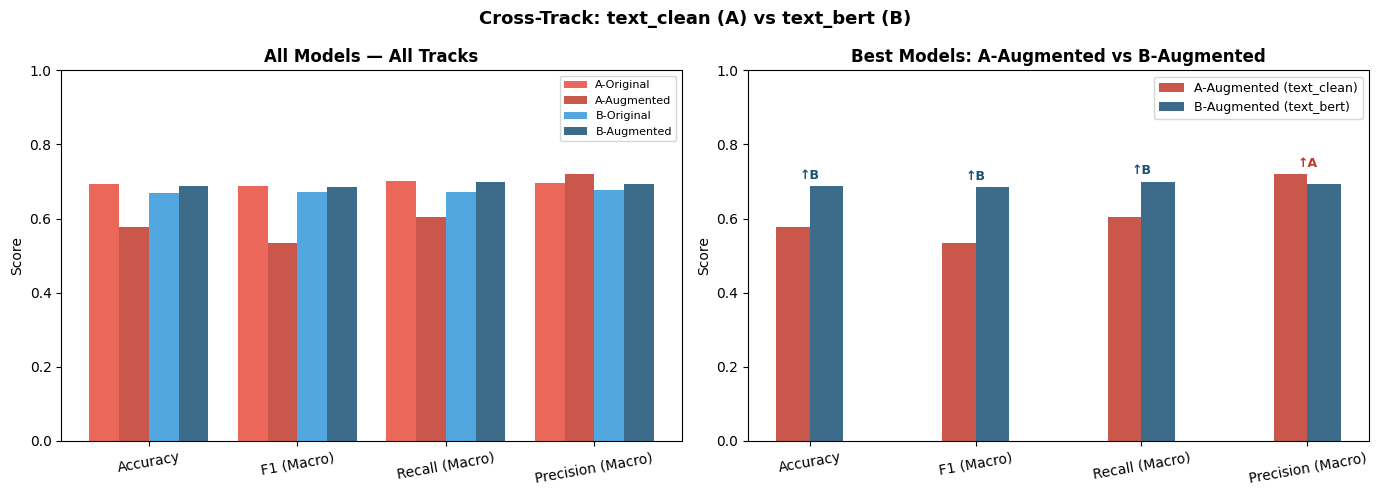


VERDICT
  Track A (text_clean) wins on 1/4 metrics
  Track B (text_bert)  wins on 3/4 metrics

  → Track B (BERT-friendly preprocessing) lebih unggul secara keseluruhan

✅ Cross-track comparison complete!
   Chart saved → c:\Users\mikba\Downloads\Documents\LPDP-SentimentAnalysis\outputs\cross_track_comparison.png


In [19]:
print("="*70)
print("CROSS-TRACK COMPARISON: Track A (text_clean) vs Track B (text_bert)")
print("="*70)

# ── Summary table ──────────────────────────────────────────────────────────
cross_metrics = ['Accuracy', 'F1 (Macro)', 'Recall (Macro)', 'Precision (Macro)']
cross_a = [
    original_metrics['accuracy'],   original_metrics['f1_macro'],
    original_metrics['recall_macro'], original_metrics['precision_macro'],
]
cross_a_aug = [
    augmented_metrics['accuracy'],   augmented_metrics['f1_macro'],
    augmented_metrics['recall_macro'], augmented_metrics['precision_macro'],
]
cross_b = [
    original_metrics_b['accuracy'],   original_metrics_b['f1_macro'],
    original_metrics_b['recall_macro'], original_metrics_b['precision_macro'],
]
cross_b_aug = [
    augmented_metrics_b['accuracy'],   augmented_metrics_b['f1_macro'],
    augmented_metrics_b['recall_macro'], augmented_metrics_b['precision_macro'],
]

cross_df = pd.DataFrame({
    'Metric':           cross_metrics,
    'A-Original':       [f"{v:.4f}" for v in cross_a],
    'A-Augmented':      [f"{v:.4f}" for v in cross_a_aug],
    'B-Original':       [f"{v:.4f}" for v in cross_b],
    'B-Augmented':      [f"{v:.4f}" for v in cross_b_aug],
    'Best (Aug A vs B)': [
        'A' if av >= bv else 'B'
        for av, bv in zip(cross_a_aug, cross_b_aug)
    ]
})

print("\n" + cross_df.to_string(index=False))

# ── Visualize: 2×2 grouped bar chart ─────────────────────────────────────
fig_cross, axes_cross = plt.subplots(1, 2, figsize=(14, 5))

x_c = np.arange(len(cross_metrics))
w   = 0.2

# Left: all 4 models side by side
bars = [
    (cross_a,     '#e74c3c', 'A-Original'),
    (cross_a_aug, '#c0392b', 'A-Augmented'),
    (cross_b,     '#3498db', 'B-Original'),
    (cross_b_aug, '#1a5276', 'B-Augmented'),
]
offsets = [-1.5, -0.5, 0.5, 1.5]
for vals, color, label in bars:
    off = offsets[bars.index((vals, color, label))]
    axes_cross[0].bar(x_c + off * w, vals, w, label=label, color=color, alpha=0.85)
axes_cross[0].set_xticks(x_c)
axes_cross[0].set_xticklabels(cross_metrics, rotation=10)
axes_cross[0].set_ylabel('Score')
axes_cross[0].set_title('All Models — All Tracks', fontweight='bold')
axes_cross[0].legend(fontsize=8)
axes_cross[0].set_ylim([0, 1])

# Right: best augmented A vs B
axes_cross[1].bar(x_c - w/2, cross_a_aug, w, label='A-Augmented (text_clean)', color='#c0392b', alpha=0.85)
axes_cross[1].bar(x_c + w/2, cross_b_aug, w, label='B-Augmented (text_bert)',  color='#1a5276', alpha=0.85)
axes_cross[1].set_xticks(x_c)
axes_cross[1].set_xticklabels(cross_metrics, rotation=10)
axes_cross[1].set_ylabel('Score')
axes_cross[1].set_title('Best Models: A-Augmented vs B-Augmented', fontweight='bold')
axes_cross[1].legend(fontsize=9)
axes_cross[1].set_ylim([0, 1])
for i_c, (av, bv) in enumerate(zip(cross_a_aug, cross_b_aug)):
    winner = '↑A' if av >= bv else '↑B'
    axes_cross[1].text(i_c, max(av, bv) + 0.02, winner, ha='center',
                       fontsize=9, fontweight='bold',
                       color='#c0392b' if winner == '↑A' else '#1a5276')

plt.suptitle('Cross-Track: text_clean (A) vs text_bert (B)', fontsize=13, fontweight='bold')
plt.tight_layout()
out_cross = BASE_PATH / "outputs" / "cross_track_comparison.png"
plt.savefig(out_cross, dpi=150, bbox_inches='tight')
plt.show()

# ── Verdict ────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("VERDICT")
print('='*70)
a_wins = sum(av >= bv for av, bv in zip(cross_a_aug, cross_b_aug))
b_wins = len(cross_metrics) - a_wins
print(f"  Track A (text_clean) wins on {a_wins}/{len(cross_metrics)} metrics")
print(f"  Track B (text_bert)  wins on {b_wins}/{len(cross_metrics)} metrics")
if a_wins > b_wins:
    print("\n  → Track A (aggressive preprocessing) lebih unggul secara keseluruhan")
elif b_wins > a_wins:
    print("\n  → Track B (BERT-friendly preprocessing) lebih unggul secara keseluruhan")
else:
    print("\n  → Kedua track setara — preprocessing tidak signifikan mempengaruhi performa")
print(f"\n✅ Cross-track comparison complete!")
print(f"   Chart saved → {out_cross}")